In [1]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-2B-Instruct-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

==((====))==  Unsloth 2025.11.3: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    NVIDIA GeForce RTX 4070 SUPER. Num GPUs = 1. Max memory: 11.994 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

In [4]:
from datasets import load_dataset

In [5]:
dataset = load_dataset("invoices_dataset/mini_dataset/images", split="train")

In [6]:
dataset

Dataset({
    features: ['image', 'invoice_nr'],
    num_rows: 3
})

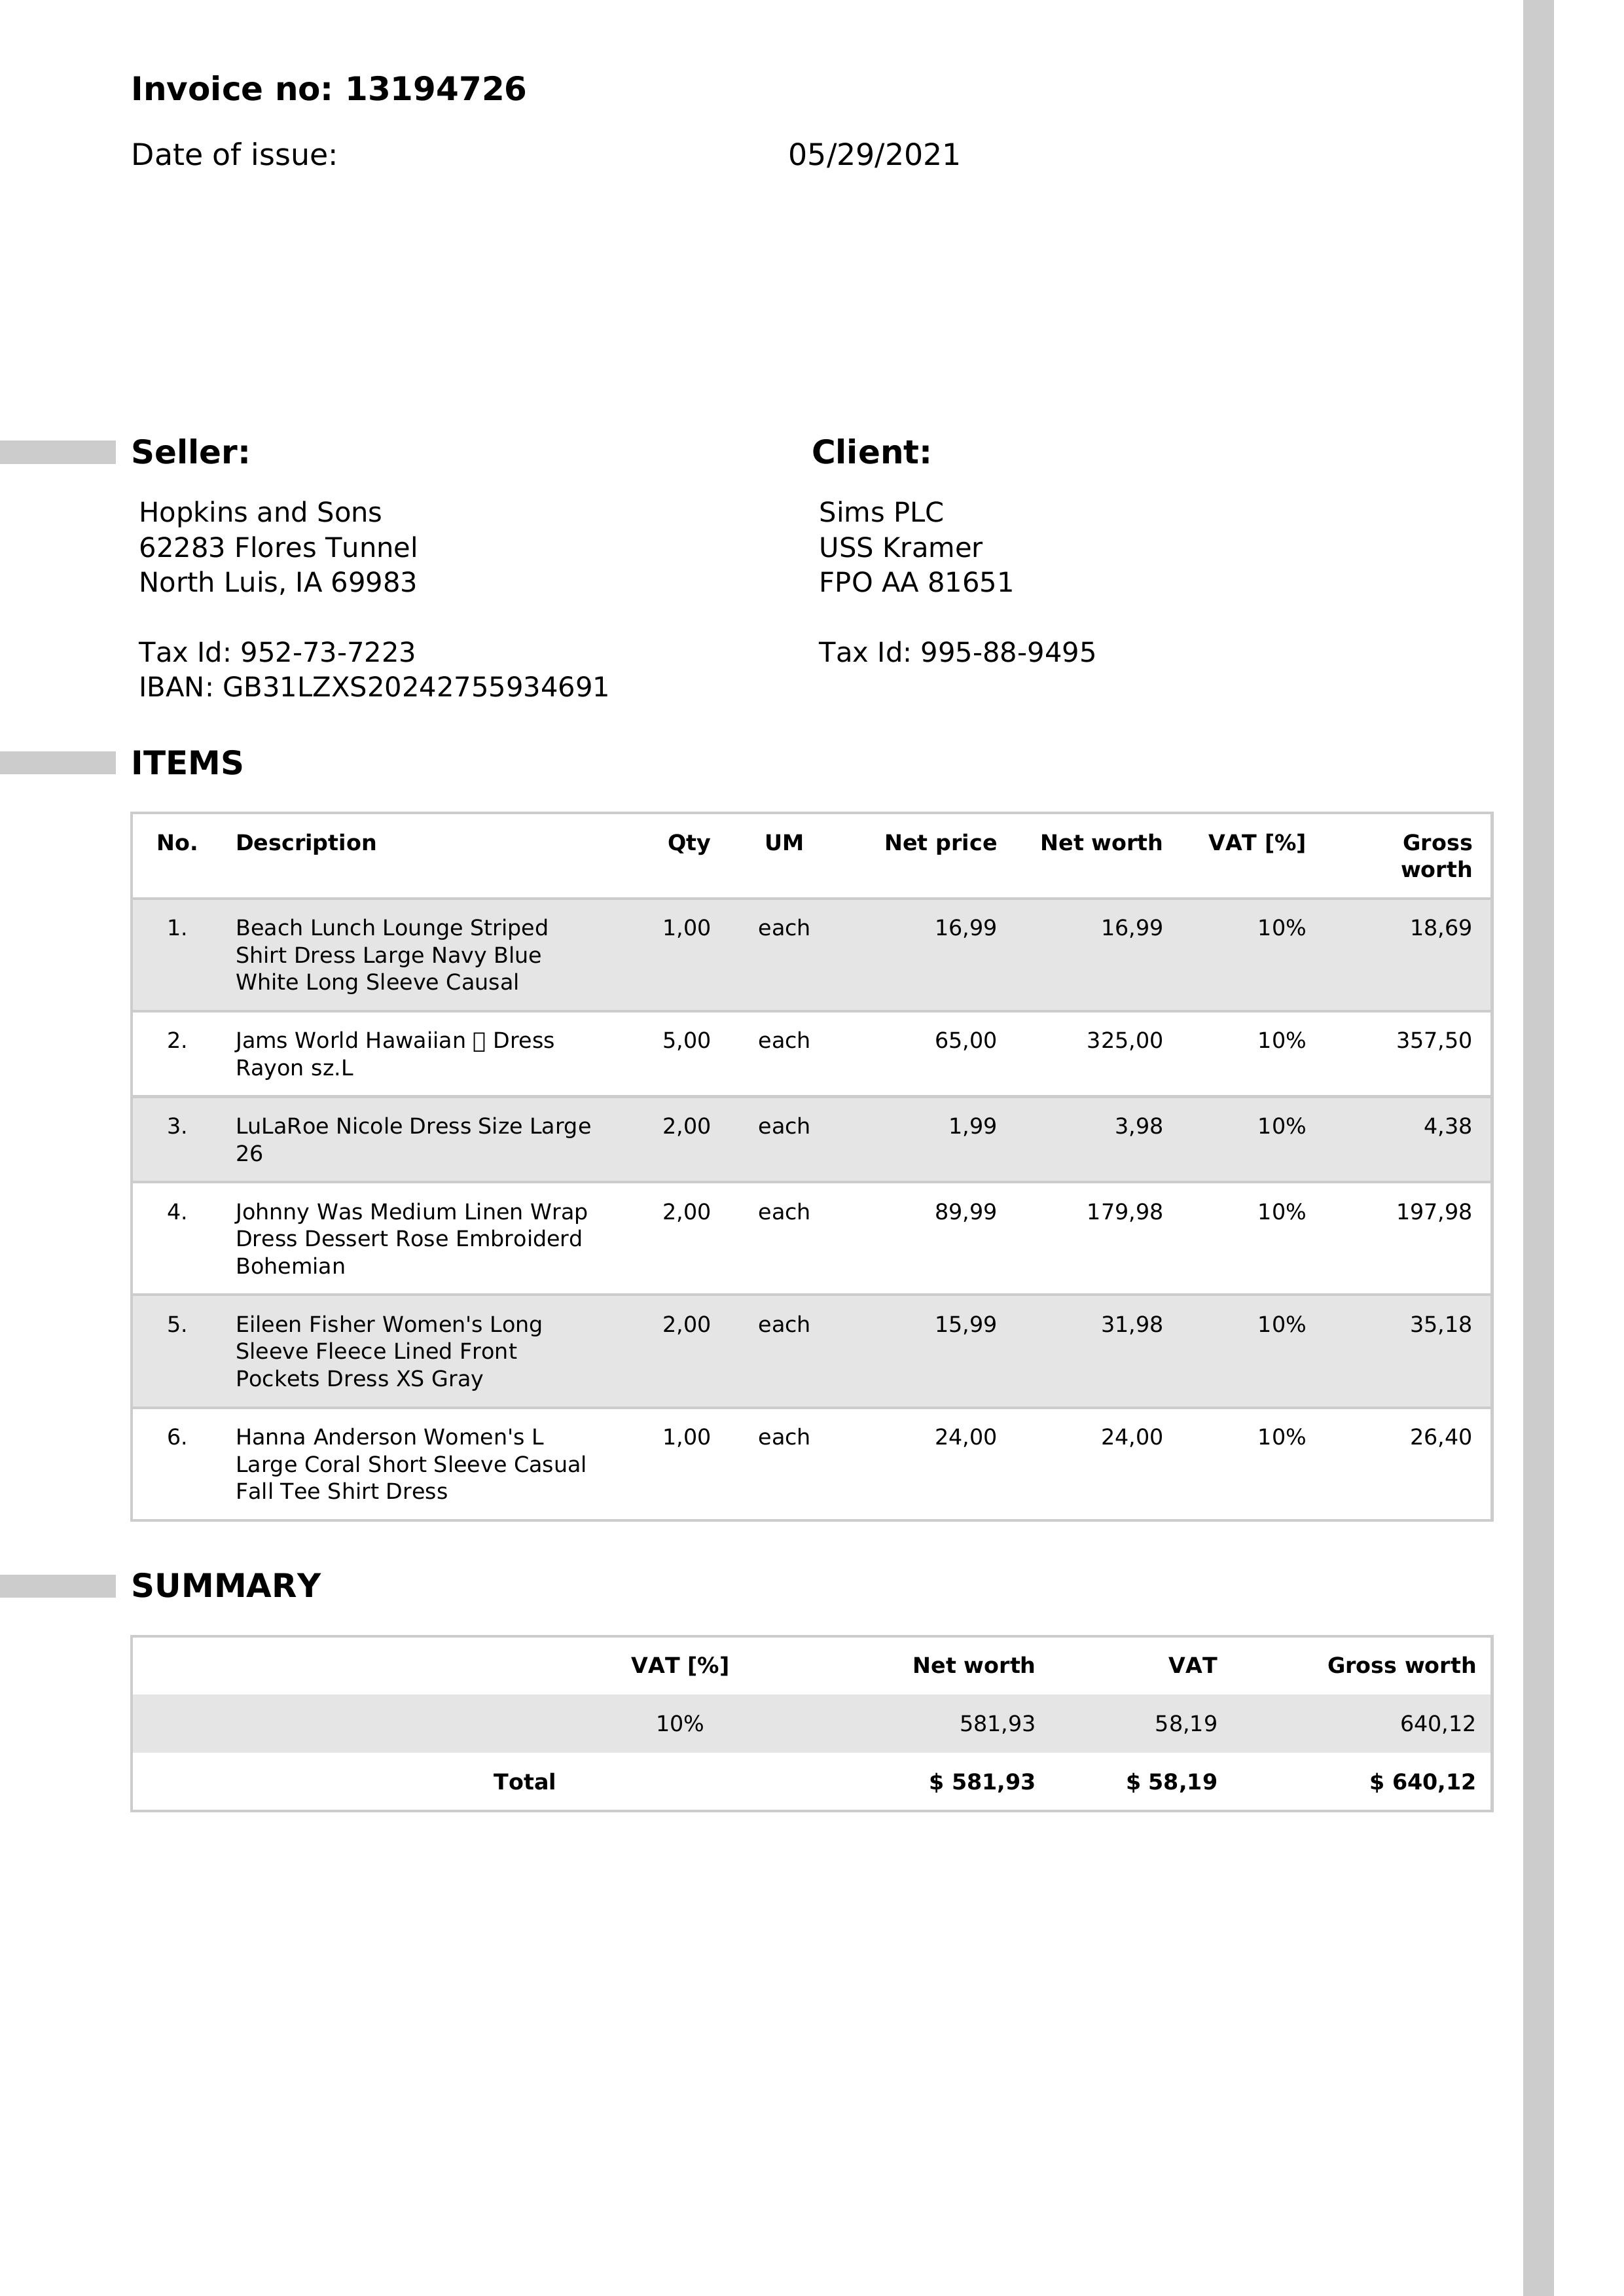

In [7]:
dataset[1]["image"]

In [9]:
dataset[1]["invoice_nr"]

13194726

In [12]:
instruction = "Read the OCR in the image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["invoice_nr"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [13]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [15]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Read the OCR in the image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 400,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Invoice no: 62517865
Date of issue: 06/02/2015

Seller:
Trujillo-Hunt
430 Mark Ferry Suite 495
Maxside, DC 65686
Tax Id: 992-71-8540
IBAN: GB73HCPH34959888432899

Client:
Lee and Sons
8552 Karen Islands
East Roger, ID 40416
Tax Id: 929-86-0601

ITEMS

| No. | Description | Qty | UM | Net price | Net worth | VAT [%] | Gross worth |
|-----|--------------|------|--------|------------|------------|--------------|--------------|
| 1. | Care & Repair of Furniture | 2,00 | each | 4,25 | 8,50 | 10% | 9,35 |

SUMMARY

| VAT [%] | Net worth | VAT | Gross worth |
|---------|-----------|------|--------------|
| 10% | 8,50 | 0,85 | 9,35 |
| Total | $ 8,50 | $ 0,85 | $ 9,35 |

---

This document is the Invoice for services related to the care and repair of furniture, delivered on 06/02/2015, under a 10% VAT rate. The total net value is $8,50, the tax (VAT) on the sale is $0.85, and the total including tax is $9,35.<|im_end|>


In [16]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [19]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3 | Num Epochs = 30 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 23,724,032 of 2,151,256,064 (1.10% trained)


Step,Training Loss
1,3.976000
2,3.976000
3,3.735600
4,3.236000
5,2.648000
6,2.149400
7,1.838100
8,1.562800
9,1.342500
10,1.158100


Unsloth: Will smartly offload gradients to save VRAM!


In [20]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Read the OCR in the image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

62517865<|im_end|>
